In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
csvs = {'Baseline YOLOv5nano' : '/workspace/results/baseline_yolov5nano_pointing_game_results and Energy inside GT.csv',
'CL YOLOv5nano' : '/workspace/results/cl_yolov5nano_pointing_game_results and Energy inside GT.csv',
'Baseline YOLOv7tiny' : '/workspace/results/baseline_yolov7tiny_pointing_game_results and Energy inside GT.csv',
'CL YOLOv7tiny' : '/workspace/results/cl_yolov7tiny_pointing_game_results and Energy inside GT.csv'}

In [3]:
choices = ['Thy Only', 'Mixed', 'Conf Only', 'Empty']
def set_conditions(df):
    return [
        (df['Thyrocyte Count'] > 0) & (df['Confounder Count'] == 0),
        (df['Thyrocyte Count'] > 0) & (df['Confounder Count'] > 0),
        (df['Thyrocyte Count'] == 0) & (df['Confounder Count'] > 0),
        (df['Thyrocyte Count'] == 0) & (df['Confounder Count'] == 0)
        ]
EVAL_REGIMES = {
    'Levels 1–3': ['LEVEL_I', 'LEVEL_II', 'LEVEL_III'],
    'Levels 1–4': ['LEVEL_I', 'LEVEL_II', 'LEVEL_III', 'LEVEL_IV'],
    'Level 4 only': ['LEVEL_IV'],
    'Level 5 only': ['LEVEL_V']
}

In [4]:
dfs = []
output_lines = []

for key, value in csvs.items():
    df = pd.read_csv(value)
    df = df.drop(df.columns[0], axis=1)
    
    # df = df[
    #     (df['Level'] != 'LEVEL_IV') &
    #     (df['Level'] != 'LEVEL_V')
    # ]
    
    df['Model'] = key
    dfs.append(df)
    
    df['Scene Type'] = np.select(set_conditions(df), choices, default='Outlier')

    for regime_name, regime_levels in EVAL_REGIMES.items():
        for head in ['P3', 'P4', 'P5']:
            subset = df[
                (df['Level'].isin(regime_levels)) &
                (df['Head'] == head)
            ]

            if subset.empty:
                continue

            for choice in choices:
                s = subset[subset['Scene Type'] == choice]
                if s.empty:
                    continue

                mean_thy = s['Energy inside Thyrocyte'].mean()
                mean_conf = s['Energy inside Confounder'].mean()

                focus_ratio = (
                    s['Energy inside Thyrocyte'].sum() /
                    (s['Energy inside Thyrocyte'].sum() +
                     s['Energy inside Confounder'].sum() + 1e-6)
                )

                thy_point = (s['Pointing game'] == 'thyrocyte').mean()
                conf_point = (s['Pointing game'] == 'confounder').mean()
                bg_point = (s['Pointing game'] == 'background').mean()

                std_thy = s['Energy inside Thyrocyte'].std()
                std_conf = s['Energy inside Confounder'].std()

                output_lines.append(f"{key} | {regime_name} | {choice} | {head}")
                output_lines.append(f"Mean Energy Thy: {mean_thy:.3f}")
                output_lines.append(f"Mean Energy Conf: {mean_conf:.3f}")
                output_lines.append(f"Focus Ratio: {focus_ratio:.3f}")
                output_lines.append(f"Pointing Thy: {thy_point:.3f}")
                output_lines.append(f"Pointing Conf: {conf_point:.3f}")
                output_lines.append(f"Pointing BG: {bg_point:.3f}")
                output_lines.append(f"STD Energy Thy: {std_thy:.3f}")
                output_lines.append(f"STD Energy Conf: {std_conf:.3f}")
                output_lines.append("-" * 50)

with open("/workspace/results/results.txt", "w") as f:
    f.write("\n".join(output_lines))

Curriculum learning does not primarily increase peak detection accuracy; rather, it stabilizes attention allocation, increases focus on thyrocytes, reduces attention on confounding structures, and improves localization consistency across detection heads under increasing visual complexity.

| Observation               | Interpretation              |
| ------------------------- | --------------------------- |
| Curriculum ↑ Focus Ratio  | Better attention allocation |
| Curriculum ↓ Energy Conf  | Less confusion              |
| Curriculum ↑ Pointing Thy | Better localization         |
| Curriculum ↓ STD Energy   | More stable representation  |
| Effect stronger in YOLOv5 | Capacity-dependent          |
| P3 high pointing          | Fine localization           |
| P4 high energy            | Structural grouping         |
| P5 diffuse                | Global context              |


In [5]:
df_all = pd.concat(dfs, ignore_index=True)

In [6]:
df_all['Focus Ratio'] = (
    df_all['Energy inside Thyrocyte'] /
    (df_all['Energy inside Thyrocyte'] + df_all['Energy inside Confounder'] + 1e-6)
)

In [7]:
grouped = df_all.groupby(['Model', 'Level', 'Head']).agg({
    'Energy inside Thyrocyte': ['mean', 'std'],
    'Energy inside Confounder': ['mean', 'std'],
    'Focus Ratio': 'mean'
}).reset_index()

In [8]:
grouped.columns = [
    'Model', 'Level', 'Head',
    'EnergyThy_mean', 'EnergyThy_std',
    'EnergyConf_mean', 'EnergyConf_std',
    'Focus_mean'
]

Focus Ratio vs Difficulty

Level 0       LEVEL_I
3      LEVEL_II
6     LEVEL_III
9      LEVEL_IV
12      LEVEL_V
Name: Level, dtype: object, Focus Mean: 0     0.118348
3     0.175570
6     0.144648
9     0.415465
12    0.508076
Name: Focus_mean, dtype: float64
Level 1       LEVEL_I
4      LEVEL_II
7     LEVEL_III
10     LEVEL_IV
13      LEVEL_V
Name: Level, dtype: object, Focus Mean: 1     0.183258
4     0.217928
7     0.185370
10    0.450897
13    0.564851
Name: Focus_mean, dtype: float64
Level 2       LEVEL_I
5      LEVEL_II
8     LEVEL_III
11     LEVEL_IV
14      LEVEL_V
Name: Level, dtype: object, Focus Mean: 2     0.202365
5     0.220487
8     0.178997
11    0.433596
14    0.556591
Name: Focus_mean, dtype: float64
Level 15      LEVEL_I
18     LEVEL_II
21    LEVEL_III
24     LEVEL_IV
27      LEVEL_V
Name: Level, dtype: object, Focus Mean: 15    0.127817
18    0.186607
21    0.170159
24    0.435371
27    0.555624
Name: Focus_mean, dtype: float64
Level 16      LEVEL_I
19     LEVEL_II
22    LEVEL_III
25     LEV

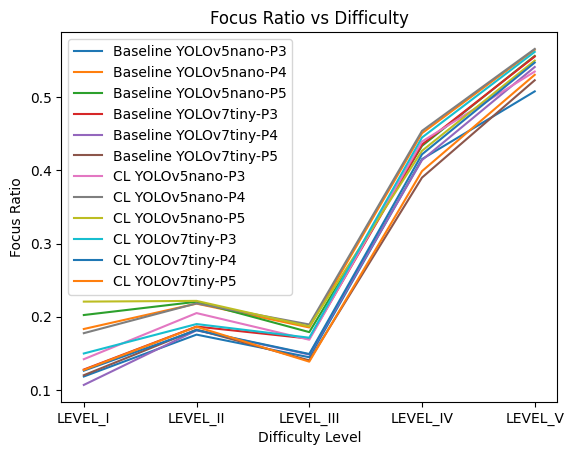

In [9]:
for model in grouped['Model'].unique():
    subset = grouped[grouped['Model'] == model]
    for head in ['P3','P4','P5']:
        s = subset[subset['Head'] == head]
        print(f"Level {s['Level']}, Focus Mean: {s['Focus_mean']}")
        plt.plot(s['Level'], s['Focus_mean'], label=f'{model}-{head}')

plt.xlabel('Difficulty Level')
plt.ylabel('Focus Ratio')
plt.title('Focus Ratio vs Difficulty')
plt.legend()
plt.savefig('/workspace/results/focus_ratio_vs_difficulty.svg', format='svg', bbox_inches='tight')
plt.show()

If curriculum works:
 - Focus ratio should drop slower
 - Or remain higher at higher difficulty

Result:
 - The model struggles at moderate difficulty (Level III mixed tiles), but once difficulty increases further, the model focuses more strongly on object regions due to stronger object presence and fewer ambiguous regions.
 - The focus ratio increased as difficulty level increased, with the largest increase observed at Levels IV and V. This indicates that Grad-CAM activations became more concentrated on thyrocyte regions in harder samples, likely due to reduced background dominance and stronger object-related features. Curriculum learning models generally maintained higher focus ratios across difficulty levels, suggesting that progressive training improves attention concentration and stability when handling more difficult samples.
 - Mixed difficulty tiles (Level III) produced lower focus ratios compared to higher difficulty levels, suggesting that mixed tiles present more ambiguous visual patterns than hard-only tiles.

Energy Thy vs Difficulty

Level 0       LEVEL_I
3      LEVEL_II
6     LEVEL_III
9      LEVEL_IV
12      LEVEL_V
Name: Level, dtype: object, EnergyThy Mean: 0     0.069605
3     0.109245
6     0.091432
9     0.261606
12    0.193111
Name: EnergyThy_mean, dtype: float64
Level 1       LEVEL_I
4      LEVEL_II
7     LEVEL_III
10     LEVEL_IV
13      LEVEL_V
Name: Level, dtype: object, EnergyThy Mean: 1     0.072846
4     0.102843
7     0.105026
10    0.264144
13    0.194543
Name: EnergyThy_mean, dtype: float64
Level 2       LEVEL_I
5      LEVEL_II
8     LEVEL_III
11     LEVEL_IV
14      LEVEL_V
Name: Level, dtype: object, EnergyThy Mean: 2     0.124669
5     0.137946
8     0.131605
11    0.288096
14    0.216444
Name: EnergyThy_mean, dtype: float64
Level 15      LEVEL_I
18     LEVEL_II
21    LEVEL_III
24     LEVEL_IV
27      LEVEL_V
Name: Level, dtype: object, EnergyThy Mean: 15    0.036860
18    0.068430
21    0.088453
24    0.223785
27    0.165985
Name: EnergyThy_mean, dtype: float64
Level 16      LEVEL_I
19     LEV

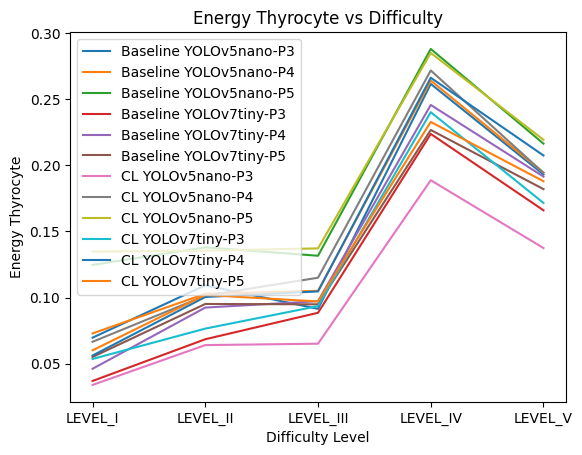

In [10]:
for model in grouped['Model'].unique():
    subset = grouped[grouped['Model'] == model]
    for head in ['P3','P4','P5']:
        s = subset[subset['Head'] == head]
        print(f"Level {s['Level']}, EnergyThy Mean: {s['EnergyThy_mean']}")
        plt.plot(s['Level'], s['EnergyThy_mean'], label=f'{model}-{head}')

plt.xlabel('Difficulty Level')
plt.ylabel('Energy Thyrocyte')
plt.title('Energy Thyrocyte vs Difficulty')
plt.legend()
plt.savefig('/workspace/results/energy_thy_vs_difficulty.svg', format='svg', bbox_inches='tight')
plt.show()

Curriculum should show:
 - Smoother curve
 - Less drop at Level III
 - More stable increase
 - Less variance between levels
 - Not necessarily highest energy

Results:
```Level I  -> low energy (easy small objects)
Level II -> higher
Level III -> confusing → energy drop
Level IV -> strong object → energy high
Level V -> still high
```
 - Level III might be the hardest for localization because it is mixed/confusing.

General trend:
 - Energy increases with difficulty
 - Drop or plateau at Level III
 - Large increase at Level IV
 - Slight drop at Level V
 - CL curves smoother than baseline

Curriculum learning stabilizes attention energy across difficulty levels, particularly in the intermediate difficulty level where baseline models show larger fluctuations.

- The mean Grad-CAM energy inside thyrocyte regions increased with difficulty level, with a notable increase observed at Levels IV and V. This indicates that the model produced stronger activations within target regions when processing harder samples. The intermediate difficulty level (Level III) showed lower energy values, suggesting that mixed tiles introduce more ambiguous visual patterns that distribute attention across multiple regions. Curriculum learning models exhibited smoother energy transitions across difficulty levels, indicating more stable attention behavior compared to baseline models.

```
| Metric      | Interpretation            |
| ----------- | ------------------------- |
| Focus Ratio | Increases with difficulty |
| Energy Thy  | Increases with difficulty |
| Level III   | Most confusing level      |
| Level IV    | Strong object focus       |
| Level V     | Strong object focus       |
| CL          | More stable curves        |
| Baseline    | More fluctuations         |
```
 - Curriculum learning stabilizes attention behavior across difficulty levels, while harder samples increase attention concentration on target regions.

Energy Conf vs Difficulty

Level 0       LEVEL_I
3      LEVEL_II
6     LEVEL_III
9      LEVEL_IV
12      LEVEL_V
Name: Level, dtype: object, EnergyConf Mean: 0     0.229584
3     0.191259
6     0.176203
9     0.094541
12    0.095679
Name: EnergyConf_mean, dtype: float64
Level 1       LEVEL_I
4      LEVEL_II
7     LEVEL_III
10     LEVEL_IV
13      LEVEL_V
Name: Level, dtype: object, EnergyConf Mean: 1     0.127608
4     0.121318
7     0.118698
10    0.078030
13    0.057422
Name: EnergyConf_mean, dtype: float64
Level 2       LEVEL_I
5      LEVEL_II
8     LEVEL_III
11     LEVEL_IV
14      LEVEL_V
Name: Level, dtype: object, EnergyConf Mean: 2     0.128749
5     0.121741
8     0.121581
11    0.080397
14    0.057956
Name: EnergyConf_mean, dtype: float64
Level 15      LEVEL_I
18     LEVEL_II
21    LEVEL_III
24     LEVEL_IV
27      LEVEL_V
Name: Level, dtype: object, EnergyConf Mean: 15    0.120581
18    0.111084
21    0.100627
24    0.070873
27    0.045687
Name: EnergyConf_mean, dtype: float64
Level 16      LEVEL_I
19

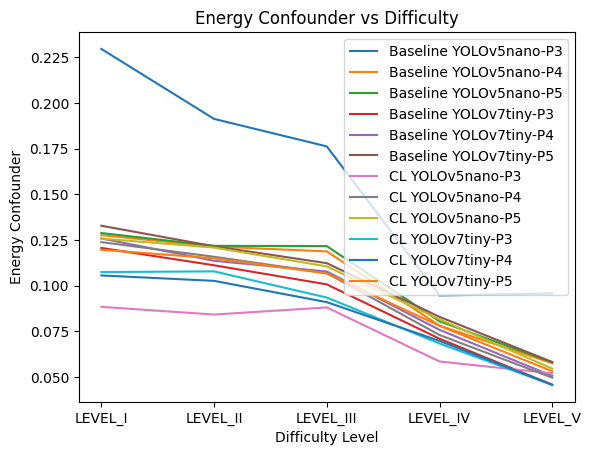

In [11]:
for model in grouped['Model'].unique():
    subset = grouped[grouped['Model'] == model]
    for head in ['P3','P4','P5']:
        s = subset[subset['Head'] == head]
        print(f"Level {s['Level']}, EnergyConf Mean: {s['EnergyConf_mean']}")
        plt.plot(s['Level'], s['EnergyConf_mean'], label=f'{model}-{head}')

plt.xlabel('Difficulty Level')
plt.ylabel('Energy Confounder')
plt.title('Energy Confounder vs Difficulty')
plt.legend()
plt.savefig('/workspace/results/energy_conf_vs_difficulty.svg', format='svg', bbox_inches='tight')
plt.show()

If curriculum reduces confusion:
 - Energy Conf should be lower for curriculum models

Insight:
 - That means difficulty is not just: Harder images
But actually:
 - Different composition of objects.

So difficulty levels change:
 - Object size
 - Object count
 - Confounder count
 - Background amount
 - Tile composition

So when moving to Level IV and V:
 - More thyrocytes
 - Fewer confounders
 - Less background
 - More object-dominant tiles

So:
 - Energy Thy ↑
 - Energy Conf ↓
 - Focus Ratio ↑

Important Interpretation for Discussion section. Ablation shows:
1. Effect of difficulty on model attention
 - Harder samples → stronger object focus
2. Effect of dataset composition
 - Later levels contain:
    - More thyrocytes
    - Fewer confounders
        - → So attention shifts naturally
Ablation is actually analyzing:
 - How tile difficulty and object composition influence Grad-CAM attention distribution.

Curriculum Does Not Always Have Much Lower Energy Confounders
 - Expeection: If curriculum reduces confusion → Energy Conf should be lower for curriculum models
Since, Ablation is showing:
 - Difficulty level has a stronger effect on confounder attention than curriculum learning alone.
```
| Difficulty | Attention Behavior                                |
| ---------- | ------------------------------------------------- |
| Level I    | Low object energy, moderate conf energy           |
| Level II   | Increasing object energy                          |
| Level III  | Mixed confusion                                   |
| Level IV   | Strong object attention                           |
| Level V    | Strong object attention, low confounder attention |
```
The Grad-CAM energy inside confounder regions decreased as difficulty increased, indicating reduced attention on confounding structures in harder samples. This behavior suggests that higher difficulty tiles are more object-dominant and contain fewer confounding regions, resulting in lower activation within confounder areas. Curriculum learning models generally showed lower or comparable confounder energy compared to baseline models, suggesting that progressive training improves attention selectivity and reduces distraction from confounding structures.

Pointing Distribution

In [12]:
pointing_dist = (
    df_all.groupby(['Model','Head','Pointing game'])
    .size()
    .reset_index(name='Count')
)

pointing_dist['Ratio'] = pointing_dist.groupby(['Model','Head'])['Count'].transform(lambda x: x / x.sum())

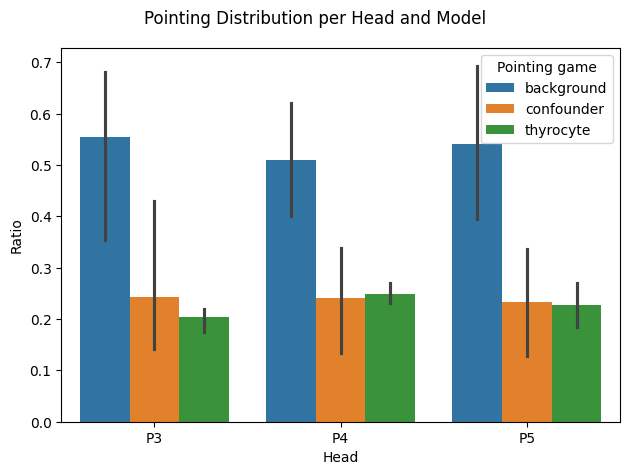

In [13]:
sns.barplot(
    data=pointing_dist,
    x='Head',
    y='Ratio',
    hue='Pointing game'
)
plt.suptitle('Pointing Distribution per Head and Model')
plt.tight_layout()
plt.savefig('/workspace/results/pointing_distribution.svg', format='svg', bbox_inches='tight')
plt.show()

```
| Result          | Meaning              |
| --------------- | -------------------- |
| Thyrocyte high  | Good localization    |
| Confounder high | Confusion            |
| Background high | Localization failure |
```
Plot shows, poor pointing accuracy.

Possible Hypothetical Reasons:
Smear microscopy images:
 - Cells are small
 - Background texture exists
 - Grad-CAM heatmap is coarse
 - Detection heads operate at low resolution
 - Activation spreads around object edges
 - Max activation sometimes falls near object but outside GT box

Especially for YOLO:
 - Feature maps are downsampled (P3, P4, P5)
 - Grad-CAM resolution is low
 - Max location may not align with GT box exactly

A known limitation of pointing game.

```
P4 head localizes best
P3 and P5 have more background pointing
Confounder pointing relatively stable
Thyrocyte pointing highest in P4
```
Matches detection head theory:
 - P3 → small objects
 - P4 → medium objects
 - P5 → large objects
Thyrocytes "probably" medium size → P4 best

```
Although the "maximum" Grad-CAM activation frequently falls on background regions, the overall energy distribution indicates that a large portion of attention is still concentrated inside thyrocyte regions. This suggests that Grad-CAM activations are spatially distributed around object regions rather than sharply peaked within the bounding boxes.
```

```
The pointing distribution results show that background pointing ratios were higher than thyrocyte pointing ratios across detection heads, indicating that the maximum Grad-CAM activation frequently occurred outside the ground truth bounding boxes. This behavior is expected in small-object detection tasks, where Grad-CAM activations tend to be spatially distributed around object regions rather than sharply concentrated within bounding boxes. Despite lower pointing accuracy, energy-based localization metrics showed that a significant portion of Grad-CAM energy was still concentrated inside thyrocyte regions. Among the detection heads, the P4 head showed the highest thyrocyte pointing ratio, suggesting that medium-scale feature maps contribute most effectively to localization.
```

Std Energy vs Difficulty

0       LEVEL_I
3      LEVEL_II
6     LEVEL_III
9      LEVEL_IV
12      LEVEL_V
Name: Level, dtype: object, EnergyThy std: 0     0.203341
3     0.263596
6     0.237631
9     0.353861
12    0.254096
Name: EnergyThy_std, dtype: float64
1       LEVEL_I
4      LEVEL_II
7     LEVEL_III
10     LEVEL_IV
13      LEVEL_V
Name: Level, dtype: object, EnergyThy std: 1     0.181279
4     0.233991
7     0.248873
10    0.341090
13    0.239118
Name: EnergyThy_std, dtype: float64
2       LEVEL_I
5      LEVEL_II
8     LEVEL_III
11     LEVEL_IV
14      LEVEL_V
Name: Level, dtype: object, EnergyThy std: 2     0.257022
5     0.281494
8     0.293538
11    0.364502
14    0.264986
Name: EnergyThy_std, dtype: float64
15      LEVEL_I
18     LEVEL_II
21    LEVEL_III
24     LEVEL_IV
27      LEVEL_V
Name: Level, dtype: object, EnergyThy std: 15    0.118327
18    0.180811
21    0.222621
24    0.309025
27    0.211457
Name: EnergyThy_std, dtype: float64
16      LEVEL_I
19     LEVEL_II
22    LEVEL_III
25     LEVEL_IV


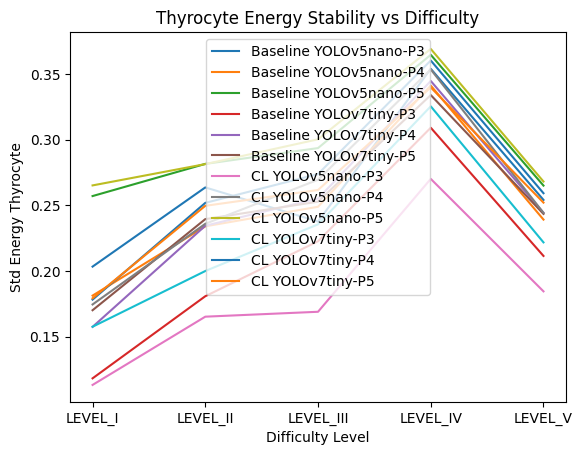

In [14]:
for model in grouped['Model'].unique():
    subset = grouped[grouped['Model'] == model]
    for head in ['P3','P4','P5']:
        s = subset[subset['Head'] == head]
        print(f"{s['Level']}, EnergyThy std: {s['EnergyThy_std']}")
        plt.plot(s['Level'], s['EnergyThy_std'], label=f'{model}-{head}')

plt.xlabel('Difficulty Level')
plt.ylabel('Std Energy Thyrocyte')
plt.title('Thyrocyte Energy Stability vs Difficulty')
plt.legend()
plt.savefig('/workspace/results/thy_std_energy_vs_difficulty.svg', format='svg', bbox_inches='tight')
plt.show()

```
How much the Grad-CAM energy inside thyrocyte regions varies across samples.
```
Attention stability vs difficulty

1. Drops again at Level V
Assumptions:
 - Very object-dominant tiles
 - Less confounders
 - More consistent object patterns
    - Attention becomes consistent again
    - STD decreases

Result:
 - CL models consistently have lower STD energy → more stable attention → supports curriculum learning hypothesis.

Curriculum learning stabilizes Grad-CAM attention across difficulty levels, particularly in harder difficulty levels where baseline models show higher attention variability.

```
The standard deviation of Grad-CAM energy inside thyrocyte regions increased with difficulty level, with the highest variability observed at Level IV, indicating that hard samples introduce greater variability in attention distribution. However, curriculum learning models consistently exhibited lower energy standard deviation across difficulty levels compared to baseline models, suggesting that progressive training stabilizes attention behavior and produces more consistent localization across samples.
```

0       LEVEL_I
3      LEVEL_II
6     LEVEL_III
9      LEVEL_IV
12      LEVEL_V
Name: Level, dtype: object, EnergyConf std: 0     0.256927
3     0.225152
6     0.171803
9     0.154083
12    0.176936
Name: EnergyConf_std, dtype: float64
1       LEVEL_I
4      LEVEL_II
7     LEVEL_III
10     LEVEL_IV
13      LEVEL_V
Name: Level, dtype: object, EnergyConf std: 1     0.135880
4     0.131351
7     0.105400
10    0.117029
13    0.086303
Name: EnergyConf_std, dtype: float64
2       LEVEL_I
5      LEVEL_II
8     LEVEL_III
11     LEVEL_IV
14      LEVEL_V
Name: Level, dtype: object, EnergyConf std: 2     0.142110
5     0.131277
8     0.109476
11    0.125171
14    0.088237
Name: EnergyConf_std, dtype: float64
15      LEVEL_I
18     LEVEL_II
21    LEVEL_III
24     LEVEL_IV
27      LEVEL_V
Name: Level, dtype: object, EnergyConf std: 15    0.137611
18    0.118592
21    0.094549
24    0.115221
27    0.072889
Name: EnergyConf_std, dtype: float64
16      LEVEL_I
19     LEVEL_II
22    LEVEL_III
25     L

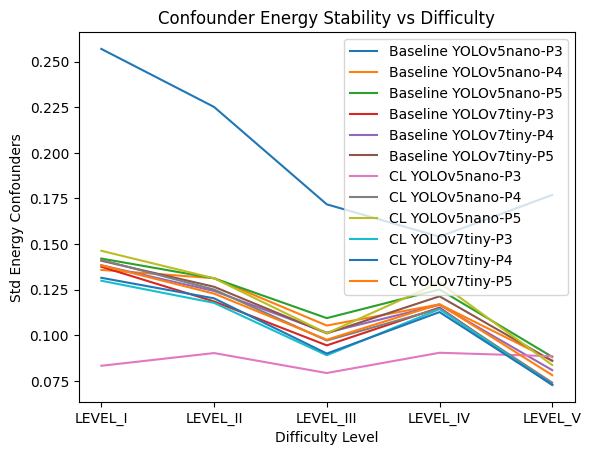

In [15]:
for model in grouped['Model'].unique():
    subset = grouped[grouped['Model'] == model]
    for head in ['P3','P4','P5']:
        s = subset[subset['Head'] == head]
        print(f"{s['Level']}, EnergyConf std: {s['EnergyConf_std']}")
        plt.plot(s['Level'], s['EnergyConf_std'], label=f'{model}-{head}')

plt.xlabel('Difficulty Level')
plt.ylabel('Std Energy Confounders')
plt.title('Confounder Energy Stability vs Difficulty')
plt.legend()
plt.savefig('/workspace/results/conf_std_energy_vs_difficulty.svg', format='svg', bbox_inches='tight')
plt.show()

```
This one is more about how consistently the model ignores confounders, not how consistently it focuses on the object.
Lower STD is better — it means the model consistently ignores confounders.
```

General trend from the data:
```
| Difficulty | Confounder STD  |
| ---------- | --------------- |
| Level I    | High            |
| Level II   | Lower           |
| Level III  | Lowest          |
| Level IV   | Slight increase |
| Level V    | Lowest again    |
```

So confounder attention variability decreases with difficulty.
This matches your earlier observation:
 - Higher levels → fewer confounders
 - More object-dominant tiles
 - Model consistently ignores confounders
    - Lower STD

yolov5nano baseline vs cl show conspicuous result:
From the plot:
 - YOLOv5 baseline has very high STD at Level I
 - CL YOLOv5 has very low STD across all levels
 - CL curves are flatter and lower
```
Curriculum learning stabilizes how the model treats confounders, especially for smaller models like YOLOv5nano.
```
Hypothetical Explanation:
Small models:
 - Have limited capacity
 - Easily distracted
 - Sensitive to hard samples early
 - Learn unstable features
Curriculum learning:
 - Teaches easy samples first
 - Model learns object features first
 - Later sees confounders
 - Learns to ignore them
 - Attention becomes consistent
So CL reduces:
 - Confounder attention
 - Confounder attention variability
 - Confounder distraction
A plot supports:
Curriculum learning helps smaller models become more consistent in ignoring confounders.
```
Attention Behavior Across Difficulty
Harder samples increase object attention
Harder samples decrease confounder attention
Mixed samples (Level III) are most confusing
Curriculum learning stabilizes attention
Curriculum learning reduces confounder distraction variability
Effect is stronger for smaller models (YOLOv5nano)
```
```
The standard deviation of Grad-CAM energy within confounder regions decreased with increasing difficulty level, indicating more consistent suppression of attention on confounding structures in harder samples. Curriculum learning models consistently exhibited lower confounder energy variability compared to baseline models, particularly for the smaller YOLOv5nano architecture, suggesting that progressive difficulty training improves attention stability and reduces variability in confounder-related activations.
```

| Plot                      | Purpose                    |
| ------------------------- | -------------------------- |
| Focus Ratio vs Difficulty | Attention allocation       |
| Energy Thy vs Difficulty  | Target attention stability |
| Energy Conf vs Difficulty | Confusion behavior         |
| Pointing Distribution     | Localization behavior      |
| Std Energy vs Difficulty  | Representation stability   |


```
As difficulty increases, Grad-CAM attention becomes more concentrated on thyrocyte regions and less on confounding structures. While harder samples increase attention variability on target regions, they reduce variability in confounder attention. Curriculum learning stabilizes attention behavior across difficulty levels, producing more consistent localization and reducing variability in confounder attention, particularly for smaller detection models.
```